In [33]:
import pypsa

for wacc in ["0700", "2700"]:
    n = pypsa.Network(f"results/nigeria_2030_wacc_{wacc}/networks/elec_s_10_ec_lcopt_1h.nc")
    solar = n.generators[n.generators.carrier == "solar"].p_nom_opt.sum() / 1e3
    ccgt = n.generators[n.generators.carrier == "CCGT"].p_nom_opt.sum() / 1e3
    ocgt = n.generators[n.generators.carrier == "OCGT"].p_nom_opt.sum() / 1e3
    bat  = n.storage_units[n.storage_units.carrier == "battery"].p_nom_opt.sum() / 1e3
    print(f"WACC {int(wacc)/100:.0f}%: solar={solar:.1f} GW, CCGT={ccgt:.1f} GW, OCGT={ocgt:.1f} GW, battery={bat:.1f} GW")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


WACC 7%: solar=5.7 GW, CCGT=3.4 GW, OCGT=8.7 GW, battery=1.7 GW
WACC 27%: solar=4.8 GW, CCGT=3.4 GW, OCGT=8.7 GW, battery=1.8 GW


In [34]:
import pypsa
import pandas as pd

for tag in ["0700", "2700"]:
    n = pypsa.Network(f"results/nigeria_2030_wacc_{tag}/networks/elec_s_10_ec_lcopt_1h.nc")
    # Capital costs reflect the WACC
    solar = n.generators[n.generators.carrier == "solar"]
    ccgt = n.generators[n.generators.carrier == "CCGT"]
    print(f"\n--- WACC tag {tag} ---")
    print(f"  Solar capital_cost: {solar.capital_cost.mean():.0f} EUR/MW/yr")
    print(f"  CCGT capital_cost:  {ccgt.capital_cost.mean():.0f} EUR/MW/yr")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units



--- WACC tag 0700 ---
  Solar capital_cost: 41706 EUR/MW/yr
  CCGT capital_cost:  162697 EUR/MW/yr

--- WACC tag 2700 ---
  Solar capital_cost: 125252 EUR/MW/yr
  CCGT capital_cost:  162697 EUR/MW/yr


In [35]:
import pypsa
n = pypsa.Network("results/nigeria_2030_wacc_0700/networks/elec_s_10_ec_lcopt_1h.nc")

for carrier in ["solar", "CCGT", "OCGT"]:
    gens = n.generators[n.generators.carrier == carrier]
    print(f"\n{carrier} ({len(gens)} units, {gens.p_nom_opt.sum()/1e3:.2f} GW):")
    print(f"  capital_cost: {gens.capital_cost.mean():.0f} EUR/MW/yr")
    print(f"  marginal_cost: {gens.marginal_cost.mean():.2f} EUR/MWh")
    print(f"  efficiency: {gens.efficiency.mean():.2f}")
    print(f"  p_nom_extendable: {gens.p_nom_extendable.unique()}")
    if hasattr(n.generators_t, "p_max_pu"):
        # Static p_max_pu is stored on n.generators
        if "p_max_pu" in gens.columns:
            print(f"  p_max_pu (static): {gens.p_max_pu.unique()}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units



solar (10 units, 5.74 GW):
  capital_cost: 41706 EUR/MW/yr
  marginal_cost: 0.01 EUR/MWh
  efficiency: 1.00
  p_nom_extendable: [ True]
  p_max_pu (static): [1. 1. 1.]

CCGT (4 units, 3.44 GW):
  capital_cost: 162697 EUR/MW/yr
  marginal_cost: 5.27 EUR/MWh
  efficiency: 0.58
  p_nom_extendable: [ True]
  p_max_pu (static): [1.]

OCGT (5 units, 8.74 GW):
  capital_cost: 78085 EUR/MW/yr
  marginal_cost: 4.79 EUR/MWh
  efficiency: 0.41
  p_nom_extendable: [ True]
  p_max_pu (static): [1.]


In [36]:
n = pypsa.Network("results/nigeria_2030_wacc_0700/networks/elec_s_10_ec_lcopt_1h.nc")
print(f"Total demand: {n.loads_t.p_set.sum().sum()/1e6:.2f} TWh")
print(f"Total generation: {n.generators_t.p.sum().sum()/1e6:.2f} TWh")

for c in ["solar", "onwind", "CCGT", "OCGT", "load shedding"]:
    cols = n.generators[n.generators.carrier == c].index
    if len(cols):
        twh = n.generators_t.p[cols].sum().sum()/1e6
        print(f"  {c}: {twh:.2f} TWh")

hyd = n.storage_units[n.storage_units.carrier == "hydro"]
if len(hyd):
    print(f"  hydro: {n.storage_units_t.p[hyd.index].clip(lower=0).sum().sum()/1e6:.2f} TWh")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Total demand: 77.99 TWh
Total generation: 70.00 TWh
  solar: 6.18 TWh
  onwind: 0.00 TWh
  CCGT: 0.01 TWh
  OCGT: 63.75 TWh
  load shedding: 0.06 TWh
  hydro: 8.26 TWh


In [32]:
n = pypsa.Network("results/nigeria_2030_wacc_0700/networks/elec_s_10_ec_lcopt_1h.nc")

print("Annual generation by carrier (TWh):")
for carrier in ["solar", "onwind", "CCGT", "OCGT"]:
    cols = n.generators[n.generators.carrier == carrier].index
    if len(cols):
        twh = n.generators_t.p[cols].sum().sum() / 1e6
        print(f"  {carrier}: {twh:.2f}")

print("\nHydro:", n.storage_units_t.p[n.storage_units[n.storage_units.carrier == "hydro"].index].clip(lower=0).sum().sum() / 1e6, "TWh")
print("Load shedding:", n.generators_t.p[n.generators[n.generators.carrier == "load shedding"].index].sum().sum() / 1e6, "TWh")
print("Total demand:", n.loads_t.p_set.sum().sum() / 1e6, "TWh")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Annual generation by carrier (TWh):
  solar: 13.78
  onwind: 0.00
  CCGT: 5.14
  OCGT: 51.06

Hydro: 8.25550612408064 TWh
Load shedding: 0.057889931319546055 TWh
Total demand: 77.99082031312142 TWh


In [8]:
# Two WACC sweeps: pure and gas-priced
WACC_TAGS = ["0700","0900","1100","1200","1300","1379",
             "1468","1600","1800","2000","2300","2700"]

PURE_RUNS = [f"nigeria_2030_wacc_{t}" for t in WACC_TAGS]
GAS_RUNS  = [f"nigeria_2030_wacc_{t}_gas" for t in ["0700","1379","2700"]]

BASELINES = {
    "B1_uniform_uncon": "cap_exp_2030_uniform_WACC",
    "B2_split_uncon":   "cap_exp_2030_split_wacc",
    "B3_uniform_ndc":   "cap_exp_2030_uniform_WACC_NDC",
    "B4_split_ndc":     "cap_exp_2030_split_wacc_NDC",
}

ALL_RUNS = PURE_RUNS + GAS_RUNS + list(BASELINES.values())
print(f"Runs to process: {len(ALL_RUNS)}")

Runs to process: 19


In [9]:
def find_network(run_name):
    d = RES / run_name
    if not d.exists():
        return None
    nets = sorted(d.glob("**/networks/*.nc"))
    return nets[0] if nets else None

def load_network(run_name):
    f = find_network(run_name)
    return pypsa.Network(f) if f else None

def get_connected(n):
    n.determine_network_topology()
    if "sub_network" not in n.buses.columns:
        return n.buses.index.tolist()
    main_sub = n.buses.sub_network.mode()[0]
    return n.buses.index[n.buses.sub_network == main_sub].tolist()

In [10]:
def summarise(n, label, wacc=None, constraint=None, gas_price=None):
    eurusd = 1.0 / 0.7532

    connected = get_connected(n)
    gens = n.generators[n.generators.bus.isin(connected)]
    sto  = n.storage_units[n.storage_units.bus.isin(connected)]

    row = {"run": label, "wacc": wacc, "constraint": constraint, "gas_price": gas_price}

    # Installed capacity (GW)
    cap = gens.groupby("carrier").p_nom_opt.sum() / 1e3
    for c in ["solar","onwind","CCGT","OCGT","oil","biomass"]:
        row[f"cap_{c}_gw"] = float(cap.get(c, 0.0))

    bat = sto[sto.carrier == "battery"]
    hyd = sto[sto.carrier == "hydro"]
    row["cap_battery_gw"] = float(bat.p_nom_opt.sum() / 1e3) if len(bat) else 0.0
    row["cap_hydro_gw"]   = float(hyd.p_nom.sum()    / 1e3) if len(hyd) else 0.0

    # Annual generation (TWh)
    gen = {}
    for c in gens.carrier.unique():
        cols = gens[gens.carrier == c].index
        if len(cols):
            gen[c] = float(n.generators_t.p[cols].sum().sum() / 1e6)
    gen["hydro"] = (float(n.storage_units_t.p[hyd.index].clip(lower=0).sum().sum() / 1e6)
                    if len(hyd) else 0.0)

    for c in ["solar","onwind","CCGT","OCGT","hydro","oil","biomass"]:
        row[f"gen_{c}_twh"] = gen.get(c, 0.0)

    # Load shedding (PyPSA-Earth models this as a generator)
    shed_gens = gens[gens.carrier == "load shedding"]
    shed_twh = float(n.generators_t.p[shed_gens.index].sum().sum() / 1e6) if len(shed_gens) else 0.0

    load_cols = [c for c in n.loads_t.p_set.columns if c in connected]
    demand_twh = n.loads_t.p_set[load_cols].sum().sum() / 1e6
    row["demand_twh"]  = demand_twh
    row["served_twh"]  = demand_twh - shed_twh
    row["shed_twh"]    = shed_twh
    row["shed_pct"]    = 100 * shed_twh / demand_twh if demand_twh else 0.0

    row["gen_total_twh"] = sum(v for k, v in gen.items() if k != "load shedding")

    tot = row["gen_total_twh"]
    if tot > 0:
        row["share_solar_pct"] = 100 * row["gen_solar_twh"]  / tot
        row["share_wind_pct"]  = 100 * row["gen_onwind_twh"] / tot
        row["share_renew_pct"] = 100 * (row["gen_solar_twh"] + row["gen_onwind_twh"] + row["gen_hydro_twh"]) / tot
        row["share_gas_pct"]   = 100 * (row["gen_CCGT_twh"] + row["gen_OCGT_twh"]) / tot
    else:
        for k in ["share_solar_pct","share_wind_pct","share_renew_pct","share_gas_pct"]:
            row[k] = 0.0

    # Emissions (Mt CO2)
    co2_map = n.carriers["co2_emissions"].reindex(gens.carrier.unique()).fillna(0.0)
    eff = gens.efficiency.replace(0, np.nan)
    fuel_mwh = n.generators_t.p[gens.index].div(eff, axis=1)
    emissions_t = fuel_mwh.mul(gens.carrier.map(co2_map), axis=1).sum().sum()
    row["emissions_mt_co2"] = emissions_t / 1e6

    # Cost (USD)
    gen_capex  = ((gens.p_nom_opt - gens.p_nom).clip(lower=0) * gens.capital_cost).sum()
    gen_opex   = (n.generators_t.p[gens.index] * gens.marginal_cost).sum().sum()
    lines_new  = (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0) if "s_nom_opt" in n.lines.columns else 0
    line_capex = (lines_new * n.lines.capital_cost).sum() if "s_nom_opt" in n.lines.columns else 0.0
    storage_capex = (sto.capital_cost * sto.p_nom_opt).sum()
    total_cost_eur = gen_capex + gen_opex + line_capex + storage_capex

    row["cost_gen_capex_bn_usd"]     = gen_capex    * eurusd / 1e9
    row["cost_gen_opex_bn_usd"]      = gen_opex     * eurusd / 1e9
    row["cost_line_capex_bn_usd"]    = float(line_capex) * eurusd / 1e9
    row["cost_storage_capex_bn_usd"] = float(storage_capex) * eurusd / 1e9
    row["total_cost_bn_usd"]         = total_cost_eur * eurusd / 1e9
    row["cost_per_mwh_usd"]          = (total_cost_eur * eurusd) / (row["served_twh"] * 1e6) if row["served_twh"] else np.nan

    # Transmission
    if "s_nom_opt" in n.lines.columns:
        row["line_capacity_gwkm"] = float((n.lines.s_nom_opt * n.lines.length).sum() / 1e3)
    else:
        row["line_capacity_gwkm"] = 0.0

    return row

In [11]:
rows = []

# Pure WACC sweep
for t in WACC_TAGS:
    name = f"nigeria_2030_wacc_{t}"
    n = load_network(name)
    if n is None:
        print(f"MISSING: {name}"); continue
    wacc = int(t) / 10000.0
    rows.append(summarise(n, name, wacc=wacc, constraint="pure"))
    print(f"OK pure: {name}")

# Gas-price sweep
for t in ["0700","1379","2700"]:
    name = f"nigeria_2030_wacc_{t}_gas"
    n = load_network(name)
    if n is None:
        print(f"MISSING: {name}"); continue
    wacc = int(t) / 10000.0
    rows.append(summarise(n, name, wacc=wacc, constraint="gas_sweep"))
    print(f"OK gas: {name}")

# Baselines
for label, name in BASELINES.items():
    n = load_network(name)
    if n is None:
        print(f"MISSING: {label} ({name})"); continue
    rows.append(summarise(n, name, constraint=label))
    print(f"OK baseline: {label}")

df = pd.DataFrame(rows)
df.to_csv(OUT / "master_usd.csv", index=False)
print(f"\nTotal rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


OK pure: nigeria_2030_wacc_0700
OK pure: nigeria_2030_wacc_0900


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


OK pure: nigeria_2030_wacc_1100
OK pure: nigeria_2030_wacc_1200


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


...

OK pure: nigeria_2030_wacc_2300
OK pure: nigeria_2030_wacc_2700
MISSING: nigeria_2030_wacc_0700_gas
MISSING: nigeria_2030_wacc_1379_gas
MISSING: nigeria_2030_wacc_2700_gas


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


OK baseline: B1_uniform_uncon
OK baseline: B2_split_uncon


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


OK baseline: B3_uniform_ndc
OK baseline: B4_split_ndc

Total rows: 16
Columns: ['run', 'wacc', 'constraint', 'gas_price', 'cap_solar_gw', 'cap_onwind_gw', 'cap_CCGT_gw', 'cap_OCGT_gw', 'cap_oil_gw', 'cap_biomass_gw', 'cap_battery_gw', 'cap_hydro_gw', 'gen_solar_twh', 'gen_onwind_twh', 'gen_CCGT_twh', 'gen_OCGT_twh', 'gen_hydro_twh', 'gen_oil_twh', 'gen_biomass_twh', 'demand_twh', 'served_twh', 'shed_twh', 'shed_pct', 'gen_total_twh', 'share_solar_pct', 'share_wind_pct', 'share_renew_pct', 'share_gas_pct', 'emissions_mt_co2', 'cost_gen_capex_bn_usd', 'cost_gen_opex_bn_usd', 'cost_line_capex_bn_usd', 'cost_storage_capex_bn_usd', 'total_cost_bn_usd', 'cost_per_mwh_usd', 'line_capacity_gwkm']


In [12]:
pure = df[df.constraint == "pure"].sort_values("wacc").reset_index(drop=True)

rq1 = pure[[
    "wacc","cap_solar_gw","cap_CCGT_gw","cap_OCGT_gw","cap_battery_gw",
    "gen_solar_twh","gen_CCGT_twh","gen_OCGT_twh","gen_hydro_twh",
    "share_renew_pct","share_gas_pct",
    "shed_pct","emissions_mt_co2","cost_per_mwh_usd",
]].copy()
rq1["wacc"] = (rq1.wacc * 100).round(2)
rq1.round(2).to_csv(OUT / "rq1_pure_sweep.csv", index=False)
rq1.round(2)

,wacc,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,cap_battery_gw,gen_solar_twh,gen_CCGT_twh,gen_OCGT_twh,gen_hydro_twh,share_renew_pct,share_gas_pct,shed_pct,emissions_mt_co2,cost_per_mwh_usd
0,7.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
1,9.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
2,11.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
3,12.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
4,13.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
5,13.79,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
6,14.68,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
7,16.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
8,18.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47
9,20.00,2.75,3.44,28.56,0.05,4.78,5.4,53.58,8.26,18.11,81.89,0.0,27.72,37.47


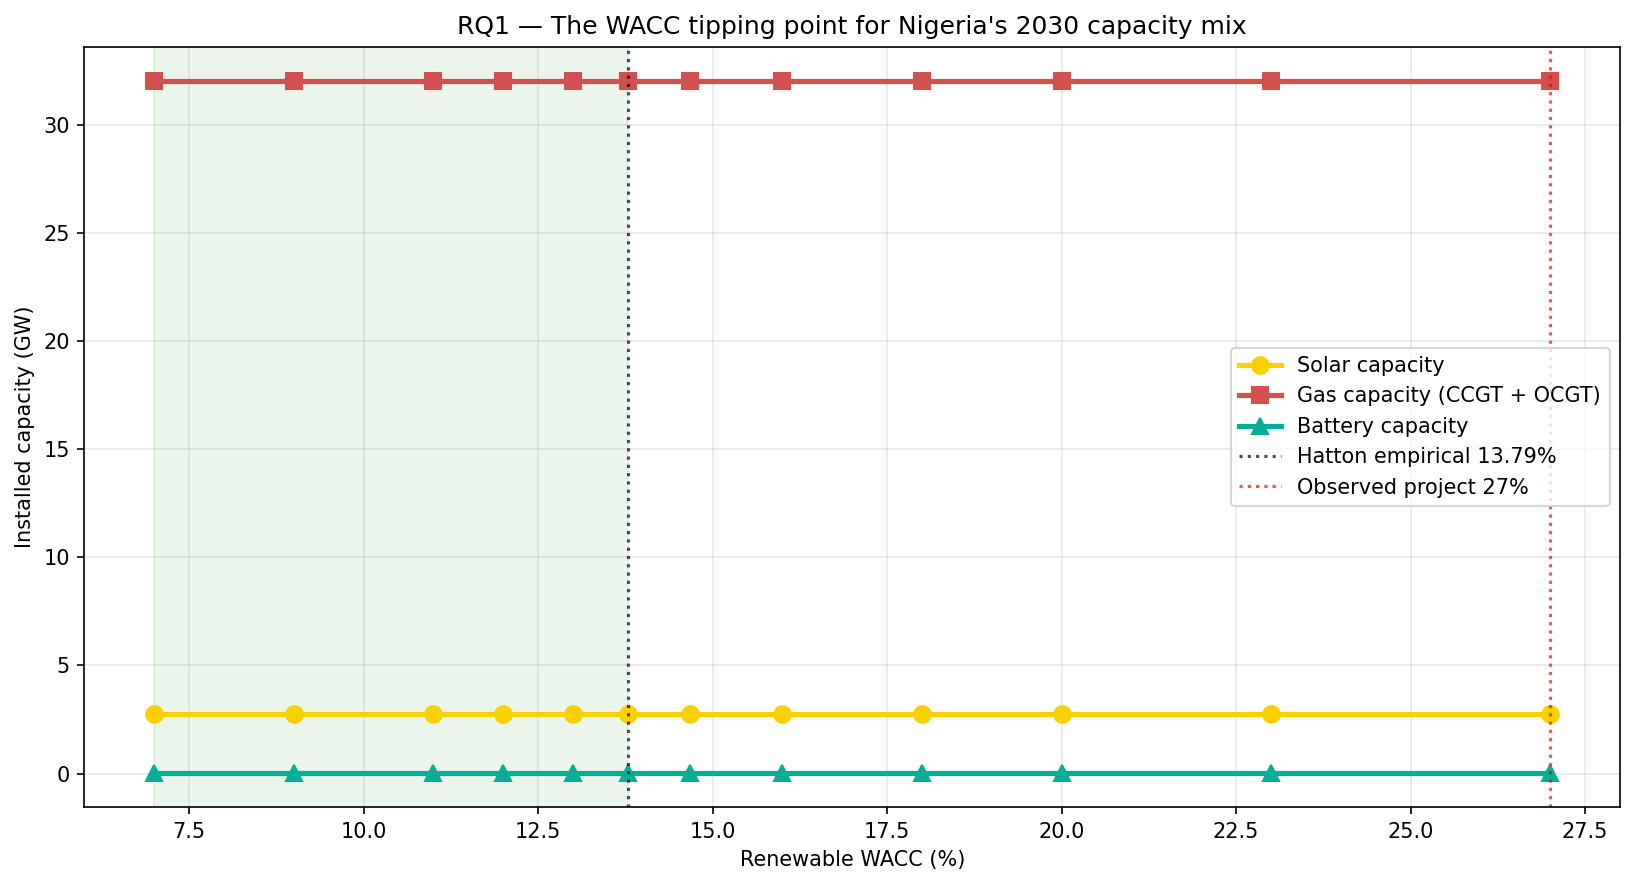

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

x = pure.wacc * 100
ax.plot(x, pure.cap_solar_gw, "o-", color="#f9d002", lw=2.5, markersize=8, label="Solar capacity")
ax.plot(x, pure.cap_CCGT_gw + pure.cap_OCGT_gw, "s-", color="#d35050", lw=2.5, markersize=8, label="Gas capacity (CCGT + OCGT)")
ax.plot(x, pure.cap_battery_gw, "^-", color="#08ad97", lw=2.5, markersize=8, label="Battery capacity")

ax.axvline(13.79, color="black", linestyle=":", alpha=0.7, label="Hatton empirical 13.79%")
ax.axvline(27,    color="red",   linestyle=":", alpha=0.7, label="Observed project 27%")
ax.axvspan(7, 13.79, alpha=0.08, color="green")

ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("Installed capacity (GW)")
ax.set_title("RQ1 — The WACC tipping point for Nigeria's 2030 capacity mix")
ax.legend(loc="center right")
plt.tight_layout()
plt.savefig(OUT / "fig_rq1_tipping.png", bbox_inches="tight")
plt.show()

In [14]:
def first_cross(sub, cond):
    sub = sub.sort_values("wacc")
    hit = sub[cond]
    return float(hit.wacc.iloc[0] * 100) if len(hit) else None

rq1_inf = pd.DataFrame([{
    "metric": "Solar capacity > gas capacity",
    "wacc_pct": first_cross(pure, pure.cap_solar_gw >= pure.cap_CCGT_gw + pure.cap_OCGT_gw),
},{
    "metric": "Solar generation > gas generation",
    "wacc_pct": first_cross(pure, pure.gen_solar_twh >= pure.gen_CCGT_twh + pure.gen_OCGT_twh),
},{
    "metric": "Renewable share > 30%",
    "wacc_pct": first_cross(pure, pure.share_renew_pct >= 30),
},{
    "metric": "Renewable share > 50%",
    "wacc_pct": first_cross(pure, pure.share_renew_pct >= 50),
},{
    "metric": "Renewable share > 70%",
    "wacc_pct": first_cross(pure, pure.share_renew_pct >= 70),
},{
    "metric": "Emissions < 10 Mt CO2",
    "wacc_pct": first_cross(pure, pure.emissions_mt_co2 <= 10),
}])
rq1_inf.to_csv(OUT / "rq1_inflection.csv", index=False)
rq1_inf

,metric,wacc_pct
0,Solar capacity > gas capacity,None
1,Solar generation > gas generation,None
2,Renewable share > 30%,None
3,Renewable share > 50%,None
4,Renewable share > 70%,None
5,Emissions < 10 Mt CO2,None


In [15]:
gas = df[df.constraint == "gas_sweep"].sort_values(["wacc"]).reset_index(drop=True)

rq2 = gas[[
    "wacc","cap_solar_gw","cap_CCGT_gw","cap_OCGT_gw","cap_battery_gw",
    "gen_solar_twh","gen_CCGT_twh","gen_OCGT_twh",
    "share_renew_pct","share_gas_pct",
    "emissions_mt_co2","cost_per_mwh_usd",
]].copy()
rq2["wacc"] = (rq2.wacc * 100).round(2)
rq2.round(2).to_csv(OUT / "rq2_gas_pricing.csv", index=False)
rq2.round(2)

,wacc,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,cap_battery_gw,gen_solar_twh,gen_CCGT_twh,gen_OCGT_twh,share_renew_pct,share_gas_pct,emissions_mt_co2,cost_per_mwh_usd


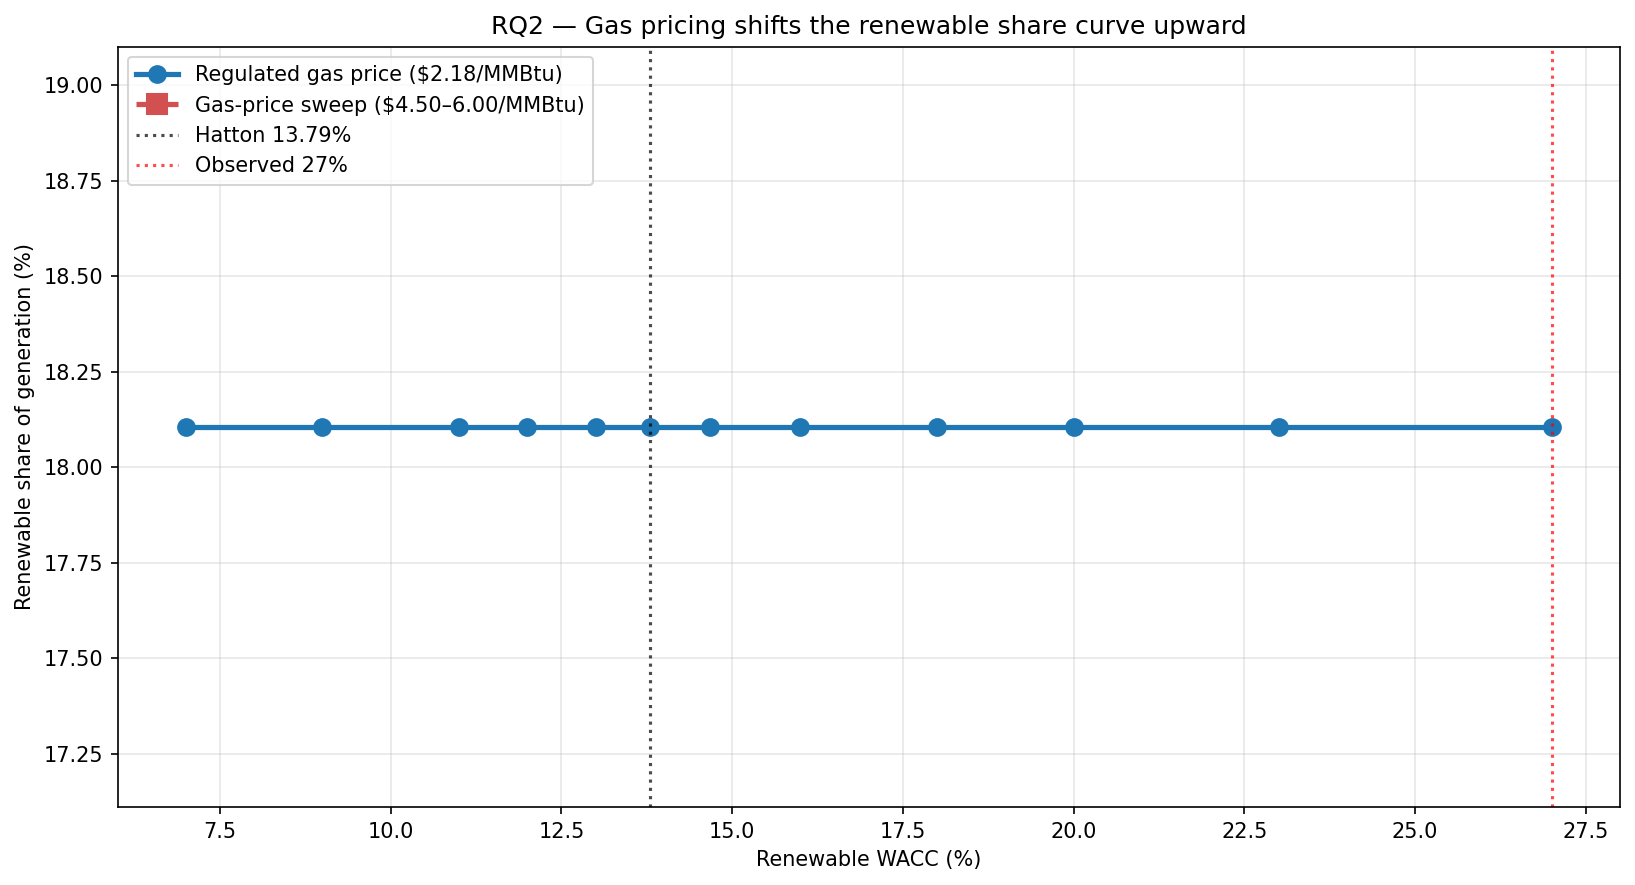

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

x = pure.wacc * 100
ax.plot(x, pure.share_renew_pct, "o-", color="#1f77b4", lw=2.5, markersize=8, label="Regulated gas price ($2.18/MMBtu)")

xg = gas.wacc * 100
ax.plot(xg, gas.share_renew_pct, "s--", color="#d35050", lw=2.5, markersize=10, label="Gas-price sweep ($4.50–6.00/MMBtu)")

ax.axvline(13.79, color="black", linestyle=":", alpha=0.7, label="Hatton 13.79%")
ax.axvline(27,    color="red",   linestyle=":", alpha=0.7, label="Observed 27%")

ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("Renewable share of generation (%)")
ax.set_title("RQ2 — Gas pricing shifts the renewable share curve upward")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_rq2_gas_price.png", bbox_inches="tight")
plt.show()

In [17]:
# Compute LCOE at each WACC from the network's own cost data

def lcoe_from_network(network_path, wacc, tech, lifetime=25):
    """Compute LCOE in USD/MWh for a technology using CRF."""
    n = pypsa.Network(network_path)
    connected = get_connected(n)
    gens = n.generators[(n.generators.bus.isin(connected)) & (n.generators.carrier == tech)]
    if len(gens) == 0:
        return np.nan
    capex = (gens.capital_cost * gens.p_nom_opt).sum() / max(gens.p_nom_opt.sum(), 1e-9)  # EUR/MW
    crf = wacc * (1 + wacc)**lifetime / ((1 + wacc)**lifetime - 1)
    annual_capex_per_mw = capex * crf                       # EUR/MW/yr
    cf = n.generators_t.p[gens.index].sum().sum() / (gens.p_nom_opt.sum() * 8760) if gens.p_nom_opt.sum() else 0
    if cf == 0:
        return np.nan
    lcoe_eur_mwh = annual_capex_per_mw / (cf * 8760)
    # Add VOM
    vom = gens.marginal_cost.mean() if "marginal_cost" in gens.columns else 0
    lcoe_eur_mwh += vom
    return lcoe_eur_mwh * (1/0.7532)

# Compute LCOE at 4 reference WACCs from the corresponding runs
ref = {
    "OECD 7.0%":    "nigeria_2030_wacc_0700",
    "Hatton 13.79%":"nigeria_2030_wacc_1379",
    "Dato 20.0%":   "nigeria_2030_wacc_2000",
    "Observed 27%":"nigeria_2030_wacc_2700",
}

lcoe_rows = []
for label, run in ref.items():
    path = find_network(run)
    if path is None:
        continue
    wacc = float(run.split("_")[-1]) / 10000.0
    lcoe_rows.append({
        "scenario": label,
        "wacc_pct": wacc * 100,
        "solar_usd_mwh": lcoe_from_network(path, wacc, "solar"),
        "ccgt_usd_mwh":  lcoe_from_network(path, wacc, "CCGT"),
        "ocgt_usd_mwh":  lcoe_from_network(path, wacc, "OCGT"),
    })

lcoe = pd.DataFrame(lcoe_rows).round(2)
lcoe.to_csv(OUT / "rq3_lcoe.csv", index=False)
lcoe

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraint

,scenario,wacc_pct,solar_usd_mwh,ccgt_usd_mwh,ocgt_usd_mwh
0,OECD 7.0%,7.00,4.54,18.82,11.10
1,Hatton 13.79%,13.79,7.58,26.77,14.29
2,Dato 20.0%,20.00,10.67,34.84,17.53
3,Observed 27%,27.00,14.29,44.28,21.32


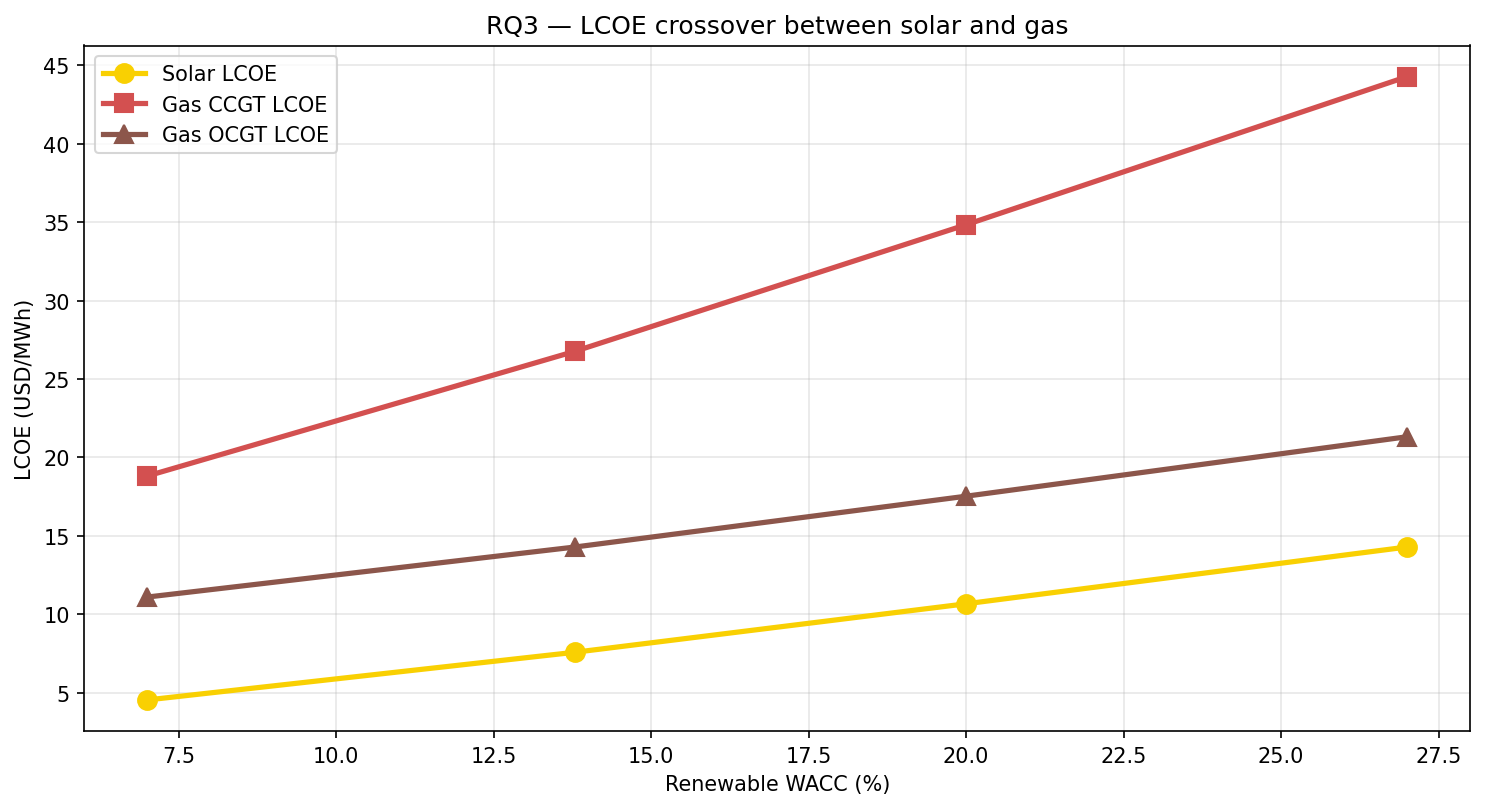

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(lcoe.wacc_pct, lcoe.solar_usd_mwh, "o-", color="#f9d002", lw=2.5, markersize=9, label="Solar LCOE")
ax.plot(lcoe.wacc_pct, lcoe.ccgt_usd_mwh,  "s-", color="#d35050", lw=2.5, markersize=9, label="Gas CCGT LCOE")
ax.plot(lcoe.wacc_pct, lcoe.ocgt_usd_mwh,  "^-", color="#8c564b", lw=2.5, markersize=9, label="Gas OCGT LCOE")

ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("LCOE (USD/MWh)")
ax.set_title("RQ3 — LCOE crossover between solar and gas")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_rq3_lcoe.png", bbox_inches="tight")
plt.show()

In [19]:
base = df[df.constraint.isin(list(BASELINES.keys()))].copy()
base = base[[
    "constraint","cap_solar_gw","cap_CCGT_gw","cap_OCGT_gw","cap_battery_gw",
    "gen_solar_twh","gen_hydro_twh","gen_CCGT_twh","gen_OCGT_twh",
    "share_renew_pct","share_gas_pct",
    "shed_pct","emissions_mt_co2","cost_per_mwh_usd",
]].round(2)
base.to_csv(OUT / "rq4_baselines.csv", index=False)
base

,constraint,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,cap_battery_gw,gen_solar_twh,gen_hydro_twh,gen_CCGT_twh,gen_OCGT_twh,share_renew_pct,share_gas_pct,shed_pct,emissions_mt_co2,cost_per_mwh_usd
12,B1_uniform_uncon,2.75,3.44,28.56,0.05,4.78,8.26,5.40,53.58,18.11,81.89,0.0,27.72,37.47
13,B2_split_uncon,2.75,3.44,28.56,0.05,4.78,8.26,5.40,53.58,18.11,81.89,0.0,27.72,37.47
14,B3_uniform_ndc,25.90,3.44,9.21,9.35,44.19,8.42,8.63,12.18,71.67,28.33,0.0,8.82,57.54
15,B4_split_ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,53.38


In [21]:
pairs = {
    "Uniform 10%":  ("cap_exp_2030_uniform_WACC",      "cap_exp_2030_uniform_WACC_NDC"),
    "Split (Hatton)": ("cap_exp_2030_split_wacc",      "cap_exp_2030_split_wacc_NDC"),
}

rows_rq4 = []
for label, (uncon_run, ndc_run) in pairs.items():
    unc = df[df.run == uncon_run]
    ndc = df[df.run == ndc_run]
    if unc.empty or ndc.empty:
        continue
    rows_rq4.append({
        "scenario": label,
        "uncon_cost_usd": float(unc.cost_per_mwh_usd.iloc[0]),
        "ndc_cost_usd":   float(ndc.cost_per_mwh_usd.iloc[0]),
        "uncon_em_mt":    float(unc.emissions_mt_co2.iloc[0]),
        "ndc_em_mt":      float(ndc.emissions_mt_co2.iloc[0]),
        "cost_premium_usd": float(ndc.cost_per_mwh_usd.iloc[0]) - float(unc.cost_per_mwh_usd.iloc[0]),
    })
rq4 = pd.DataFrame(rows_rq4).round(2)
rq4.to_csv(OUT / "rq4_ndc_premium.csv", index=False)
rq4

,scenario,uncon_cost_usd,ndc_cost_usd,uncon_em_mt,ndc_em_mt,cost_premium_usd
0,Uniform 10%,37.47,57.54,27.72,8.82,20.07
1,Split (Hatton),37.47,53.38,27.72,8.82,15.91


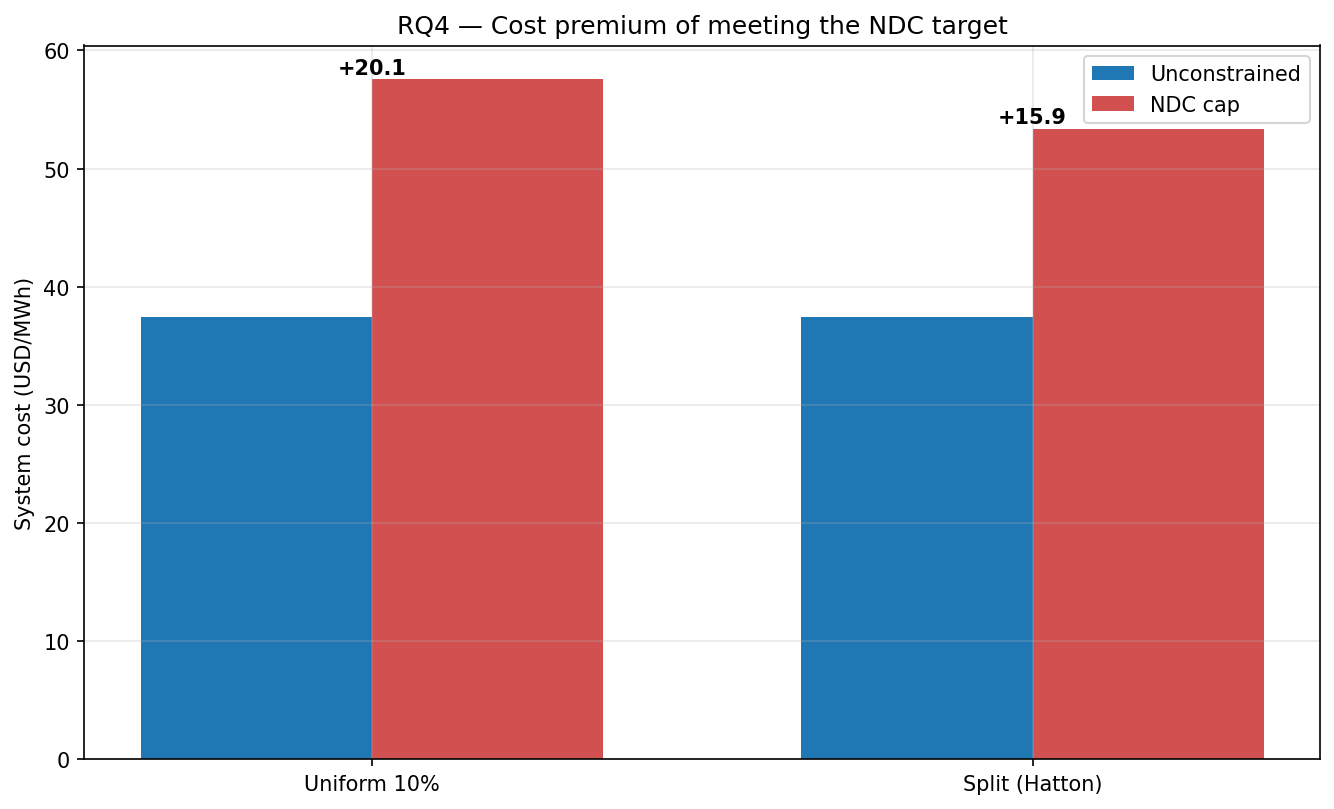

In [22]:
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(rq4))
w = 0.35
ax.bar(x - w/2, rq4.uncon_cost_usd, w, color="#1f77b4", label="Unconstrained")
ax.bar(x + w/2, rq4.ndc_cost_usd,   w, color="#d35050", label="NDC cap")

ax.set_xticks(x)
ax.set_xticklabels(rq4.scenario)
ax.set_ylabel("System cost (USD/MWh)")
ax.set_title("RQ4 — Cost premium of meeting the NDC target")
ax.legend()

for i, (u, n) in enumerate(zip(rq4.uncon_cost_usd, rq4.ndc_cost_usd)):
    ax.text(i, max(u, n) + 0.5, f"+{n-u:.1f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT / "fig_rq4_premium.png", bbox_inches="tight")
plt.show()

In [23]:
# The tipping point from RQ1
tipping = rq1_inf[rq1_inf.metric == "Solar capacity > gas capacity"].wacc_pct.values[0]

references = {
    "OECD 6%":      6.0,
    "Hatton 13.79%":13.79,
    "Dato 19.2%":   19.2,
    "Observed 27%": 27.0,
}

instrument_ceiling = {
    "Revenue de-risking": 3.0,
    "Rating de-risking":  5.0,
    "Blended finance":    6.0,
}

rq5 = []
for label, w in references.items():
    gap = max(0, w - tipping)
    rq5.append({
        "reference": label,
        "reference_wacc": w,
        "required_reduction_pp": gap,
        "achievable_with_revenue": gap <= instrument_ceiling["Revenue de-risking"],
        "achievable_with_rating":  gap <= instrument_ceiling["Rating de-risking"],
        "achievable_with_blended": gap <= instrument_ceiling["Blended finance"],
        "achievable_with_all_combined": gap <= 6.0,
    })
rq5 = pd.DataFrame(rq5).round(2)
rq5.to_csv(OUT / "rq5_feasibility.csv", index=False)
rq5

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

AttributeError: 'list' object has no attribute 'required_reduction_pp'

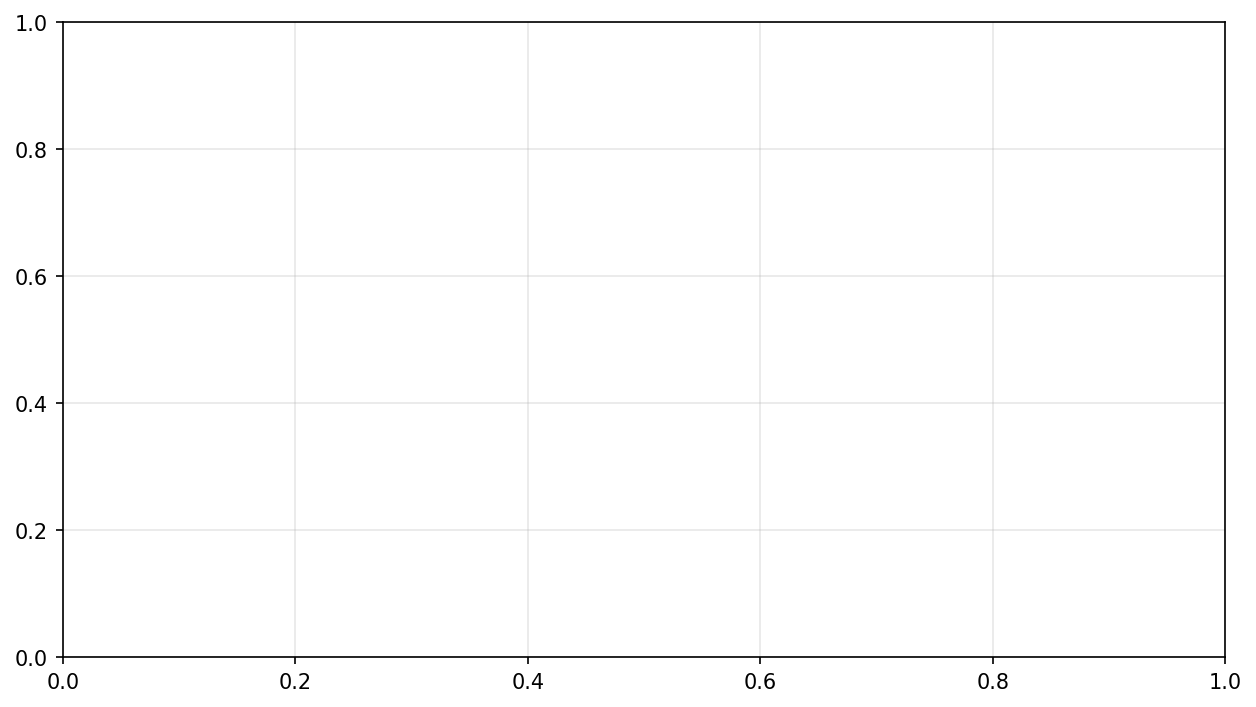

In [24]:
fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(rq5))
ax.bar(x, rq5.required_reduction_pp, color=["#2ca02c","#1f77b4","#ff7f0e","#d62728"], alpha=0.8)

for i, (label, ceiling) in enumerate(instrument_ceiling.items()):
    ax.axhline(ceiling, color="black", linestyle="--", lw=1.5, alpha=0.6,
               label=f"{label}: {ceiling:.0f} pp")

ax.set_xticks(x)
ax.set_xticklabels(rq5.reference)
ax.set_ylabel("Required WACC reduction (pp)")
ax.set_title(f"RQ5 — Policy feasibility: gap to tipping point at {tipping:.1f}% WACC")
ax.legend(fontsize=8, loc="upper left")

for i, gap in enumerate(rq5.required_reduction_pp):
    ax.text(i, gap + 0.15, f"{gap:.1f} pp", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT / "fig_rq5_feasibility.png", bbox_inches="tight")
plt.show()

In [25]:
import pypsa
n = pypsa.Network("results/nigeria_2030_wacc_1379/networks/elec_s_10_ec_lcopt_1h.nc")
print(n.generators.groupby("carrier")["p_nom_opt"].sum() / 1e3)
print()
print(n.carriers[["nice_name","co2_emissions"]].dropna())

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


carrier
CCGT              3.444002
OCGT             28.563996
load shedding    13.005307
onwind            0.000002
solar             8.019162
Name: p_nom_opt, dtype: float64

                          nice_name  co2_emissions
Carrier                                           
CCGT             Combined-Cycle Gas         0.1980
oil                             Oil         0.2571
biomass                     Biomass         0.0000
OCGT                 Open-Cycle Gas         0.1980
hydro               Reservoir & Dam         0.0000
onwind                 Onshore Wind         0.0000
solar                         Solar         0.0000
PHS            Pumped Hydro Storage         0.0000
ror                    Run of River         0.0000
AC                               Ac         0.0000
battery             Battery Storage         0.0000
load shedding         Load shedding         0.0000


In [26]:
n = pypsa.Network("results/nigeria_2030_wacc_1379/networks/elec_s_10_ec_lcopt_1h.nc")
solar = n.generators[n.generators.carrier == "solar"]
print(solar[["bus","p_nom","p_nom_opt","p_nom_max","p_nom_extendable","capital_cost"]].to_string())

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


               bus      p_nom    p_nom_opt      p_nom_max  p_nom_extendable  capital_cost
Generator                                                                                
NG0 0 solar  NG0 0  12.817717     0.000778   23117.119977              True  68988.359319
NG0 1 solar  NG0 1  28.593370     0.002330  497676.965835              True  68988.359319
NG0 2 solar  NG0 2  37.467174     0.000860   38186.826027              True  68988.359319
NG0 3 solar  NG0 3  14.789674     0.003790  704231.477720              True  68988.359319
NG0 4 solar  NG0 4  33.523261     0.000911  246302.852108              True  68988.359319
NG0 5 solar  NG0 5  18.733587  2754.339133  630453.096327              True  68988.359319
NG0 6 solar  NG0 6   7.887826     0.003079  167860.984298              True  68988.359319
NG0 7 solar  NG0 7  10.845761     0.000950   22160.882316              True  68988.359319
NG1 0 solar  NG1 0   3.943913  3077.250465   25827.216614              True  68988.359319
NG2 0 sola

In [27]:
n = pypsa.Network("networks/nigeria_2030_wacc_1379/elec_s_10_ec_lcopt_1h.nc")
connected = get_connected(n)
isolated = [b for b in n.buses.index if b not in connected]
print("Isolated buses:", isolated)
for b in isolated:
    load_cols = [c for c in n.loads_t.p_set.columns if c == b]
    if load_cols:
        print(f"{b}: mean load = {n.loads_t.p_set[load_cols].sum(axis=1).mean():.1f} MW")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


Isolated buses: ['NG1 0', 'NG2 0']
NG1 0: mean load = 365.1 MW
NG2 0: mean load = 314.9 MW


In [28]:
n = pypsa.Network("results/nigeria_2030_wacc_1379/networks/elec_s_10_ec_lcopt_1h.nc")
print(f"Objective: {n.objective:.2e} EUR")
print(f"Total generation: {n.generators_t.p.sum().sum() / 1e6:.1f} TWh")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/fowfloi/Documents/pypsa-earth/results/nigeria_2030_wacc_1379/networks/elec_s_10_ec_lcopt_1h.nc'